In [5]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

In [6]:
# Loading in the dataset of all predictions

summary = pd.read_csv("../output/summary_paddle_adhunter_adpred_pt_vars.csv")
summary

,Unnamed: 0,var,var_pred_paddle,wt_pred_paddle,var_pred_adhunter,wt_pred_adhunter,var_pos_adpred_activity,ref_pos_adpred_activity
0,0,SRCAP_Q6ZRS2_AD_198-1445|g.30710822A>T(p.Glu40...,0.147968,0.129918,24071.039062,23811.289062,NaN,NaN
1,1,SRCAP_Q6ZRS2_AD_198-1445|g.30721233C>T(p.Pro11...,-0.181365,-0.175508,42768.371094,43681.906250,NaN,NaN
2,2,SRCAP_Q6ZRS2_AD_198-1445|g.30721455G>A(p.Asp11...,-0.179097,-0.125538,46607.949219,48048.144531,NaN,NaN
3,3,SRCAP_Q6ZRS2_AD_198-1445|g.30723605C>T(p.Pro13...,-0.034244,-0.022734,29713.363281,32487.164062,NaN,NaN
4,4,SRCAP_Q6ZRS2_AD_198-1445|g.30720897C>A(p.Pro10...,-0.132803,-0.136810,38172.605469,38496.671875,NaN,NaN
...,...,...,...,...,...,...,...,...
3005,3005,NKX2-2_O95096_AD_220-273|g.21511967G>C(p.Pro26...,0.265297,0.236564,49325.363281,55944.699219,0.010054,0.009444
3006,3006,NKX2-2_O95096_AD_220-273|g.21512015G>A(p.His24...,0.279168,0.236564,52713.988281,52140.046875,0.012618,0.003549
3007,3007,NKX2-2_O95096_AD_220-273|g.21512041G>C(p.Ser23...,0.101297,0.197448,48869.820312,52295.695312,0.025123,0.016844
3008,3008,NKX2-2_O95096_AD_220-273|g.21512072C>T(p.Ala22...,0.321174,0.197448,49943.808594,52295.695312,0.016251,0.017796


In [7]:
# Adding in the original and new AA

summary["orig_AA"] = summary["var"].str.extract(r'p\.(...)')
summary["new_AA"] = summary["var"].str[-4:-1]

# Converting to 1 letter code
aa_dict = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Glu': 'E', 'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

summary["orig_AA"] = summary["orig_AA"].map(aa_dict)
summary["new_AA"] = summary["new_AA"].map(aa_dict)
summary

,Unnamed: 0,var,var_pred_paddle,wt_pred_paddle,var_pred_adhunter,wt_pred_adhunter,var_pos_adpred_activity,ref_pos_adpred_activity,orig_AA,new_AA
0,0,SRCAP_Q6ZRS2_AD_198-1445|g.30710822A>T(p.Glu40...,0.147968,0.129918,24071.039062,23811.289062,NaN,NaN,E,D
1,1,SRCAP_Q6ZRS2_AD_198-1445|g.30721233C>T(p.Pro11...,-0.181365,-0.175508,42768.371094,43681.906250,NaN,NaN,P,S
2,2,SRCAP_Q6ZRS2_AD_198-1445|g.30721455G>A(p.Asp11...,-0.179097,-0.125538,46607.949219,48048.144531,NaN,NaN,D,N
3,3,SRCAP_Q6ZRS2_AD_198-1445|g.30723605C>T(p.Pro13...,-0.034244,-0.022734,29713.363281,32487.164062,NaN,NaN,P,L
4,4,SRCAP_Q6ZRS2_AD_198-1445|g.30720897C>A(p.Pro10...,-0.132803,-0.136810,38172.605469,38496.671875,NaN,NaN,P,T
...,...,...,...,...,...,...,...,...,...,...
3005,3005,NKX2-2_O95096_AD_220-273|g.21511967G>C(p.Pro26...,0.265297,0.236564,49325.363281,55944.699219,0.010054,0.009444,P,A
3006,3006,NKX2-2_O95096_AD_220-273|g.21512015G>A(p.His24...,0.279168,0.236564,52713.988281,52140.046875,0.012618,0.003549,H,Y
3007,3007,NKX2-2_O95096_AD_220-273|g.21512041G>C(p.Ser23...,0.101297,0.197448,48869.820312,52295.695312,0.025123,0.016844,S,C
3008,3008,NKX2-2_O95096_AD_220-273|g.21512072C>T(p.Ala22...,0.321174,0.197448,49943.808594,52295.695312,0.016251,0.017796,A,T


In [ ]:
    cmap_bound = max(abs(max(relev_cols["activ_diff_" + predictor_name + " mean"])),
                     abs(min(relev_cols["activ_diff_" + predictor_name + " mean"])))


NameError: name 'relev_cols' is not defined

In [15]:
def plot_2_heatmaps(summary_df, predictor_name, var_col_name, ref_col_name):
    sns.set_context('paper')
    sns.set_style("ticks")

    # Calculating activitoy difference
    summary_df["activ_diff_" + predictor_name] = summary_df[var_col_name] - summary_df[ref_col_name]

    # Z-scores
    summary_df["activ_diff_" + predictor_name] = (summary_df["activ_diff_" + predictor_name] - np.mean(summary_df["activ_diff_" + predictor_name])) / np.std(summary_df["activ_diff_" + predictor_name])
    relev_cols = summary_df[["orig_AA", "new_AA", "activ_diff_" + predictor_name]]
    
    # Making a matrix  to prepare for heatmap
    relev_cols = relev_cols.groupby(["orig_AA", "new_AA"]).agg(['mean', 'count']).reset_index()
    relev_cols.columns = [' '.join(col).strip() for col in relev_cols.columns.values]

    #display(relev_cols)
    # Formatting as pivot table where values are averages
    pivot_relev_cols = pd.pivot(relev_cols, values = "activ_diff_" + predictor_name + " mean", 
                                                index = "new_AA", columns = "orig_AA")

    # format rows and cols in this order
    AA_order = ["D", "E", "R", "K", "W", "F", "Y", "L", "M", "I", "V", "A", "S", "T", "N", "Q", "H", "C", "G", "P"]
    pivot_relev_cols = pivot_relev_cols.reindex(AA_order, axis = 0)
    pivot_relev_cols = pivot_relev_cols.reindex(AA_order, axis = 1)

    # cmap_bound = max(abs(max(relev_cols["activ_diff_" + predictor_name + " mean"])),
    #                  abs(min(relev_cols["activ_diff_" + predictor_name + " mean"])))
    # print(cmap_bound)

    # Based on printing out for all
    cmap_bound = 4.76
    
    fig, ax = plt.subplots(figsize=(4.5, 3.6), dpi = 300)
    sns.heatmap(pivot_relev_cols, ax = ax, 
                cmap = "coolwarm", 
                vmin = -1 * cmap_bound, 
                vmax = cmap_bound, 
                cbar_kws = dict(location="right", label = "Average Variant Activity Difference"))
    plt.yticks(rotation = 0)
    plt.xlabel("Reference")
    plt.ylabel("Variant")
    plt.title(predictor_name)
    plt.show()

    # PLOT 2
    # MAKING a scatter plot where size is the count
    
    # Normalize the values
    relev_cols['normalized_mean'] = (
        relev_cols["activ_diff_" + predictor_name + " mean"] - cmap_bound
    ) / (2 * cmap_bound)  # Normalization to the range [-1, 1]

    sns.set_context('talk')
    sns.set_style('whitegrid')
    plt.figure(figsize=(6, 6), dpi = 300)

    # Order cols


    relev_cols['orig_AA'] = relev_cols['orig_AA'].map(dict(zip(AA_order, np.arange(20))))
    relev_cols['new_AA'] = 20 - relev_cols['new_AA'].map(dict(zip(AA_order, np.arange(20))))

    sns.scatterplot(
        data=relev_cols,
        x="orig_AA",
        y="new_AA",
        hue="activ_diff_" + predictor_name + " mean",  # Color by mean activity difference
        size="activ_diff_" + predictor_name + " count",  # Size by count
        #sizes=(50, 260),  # Define a size range for the markers
        palette="coolwarm",  # Use the coolwarm colormap
        #legend="full"  # Show the full legend
        legend = False,
        marker = "s"
    )
    plt.grid(False)

    plt.yticks(np.arange(21), labels = [""] + list(reversed(AA_order)));
    plt.xticks(np.arange(20), labels = AA_order);
    plt.ylim(0.5, 20.5)
    plt.xlim(-0.5, 19.5)
    
    for i in np.arange(20):
        plt.axvline(i + 0.5, color = "black", alpha = 0.1, linewidth = 1)
        plt.axhline(i + 0.5, color = "black", alpha = 0.1, linewidth = 1)
    
    plt.xlabel("Reference")
    plt.title(predictor_name)
    plt.ylabel("Variant");


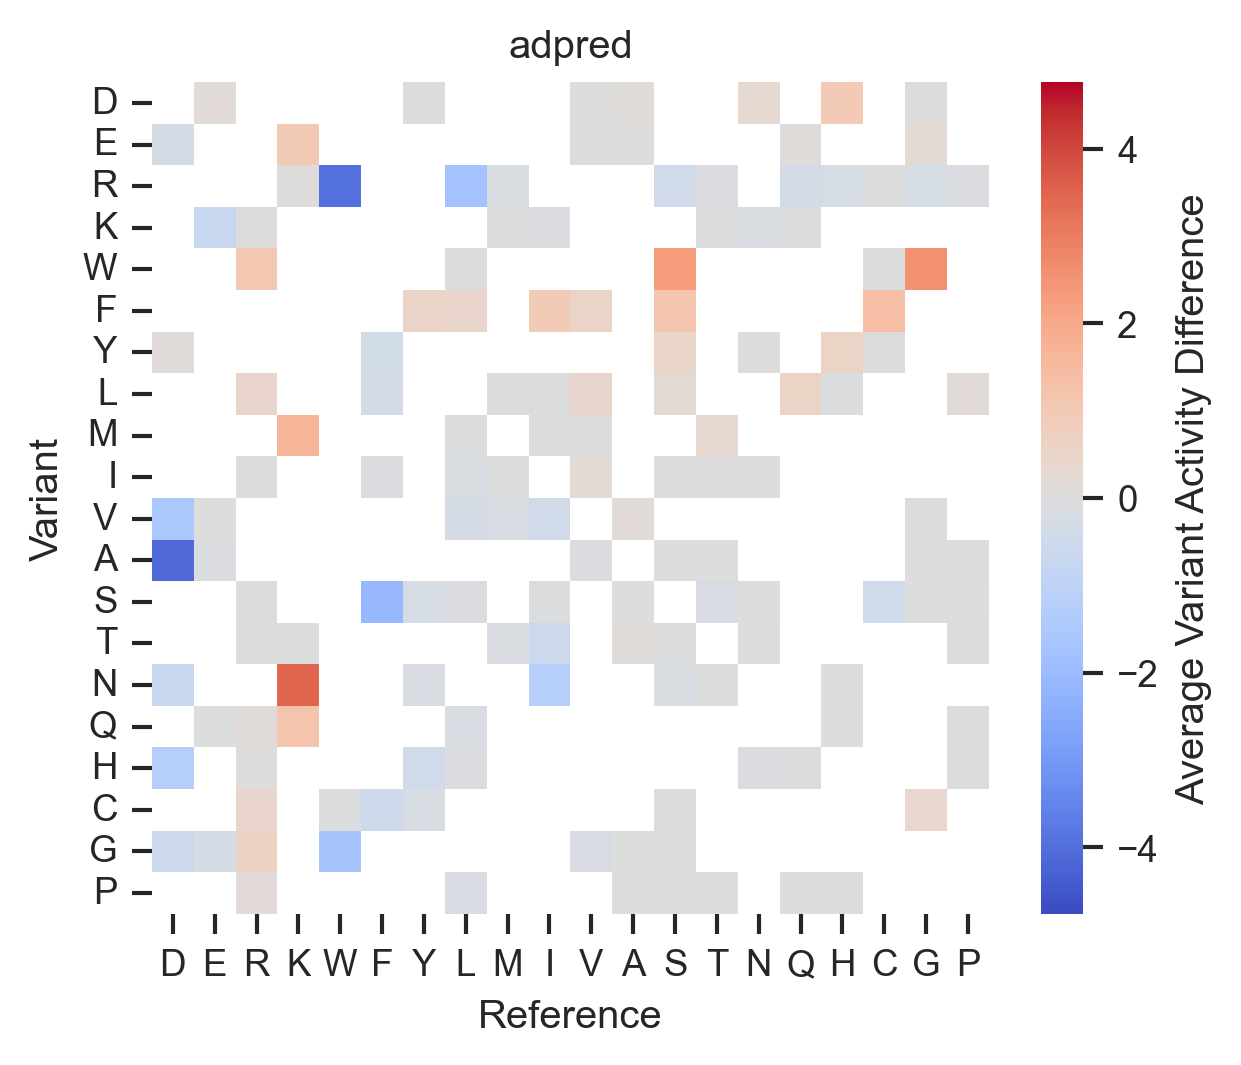

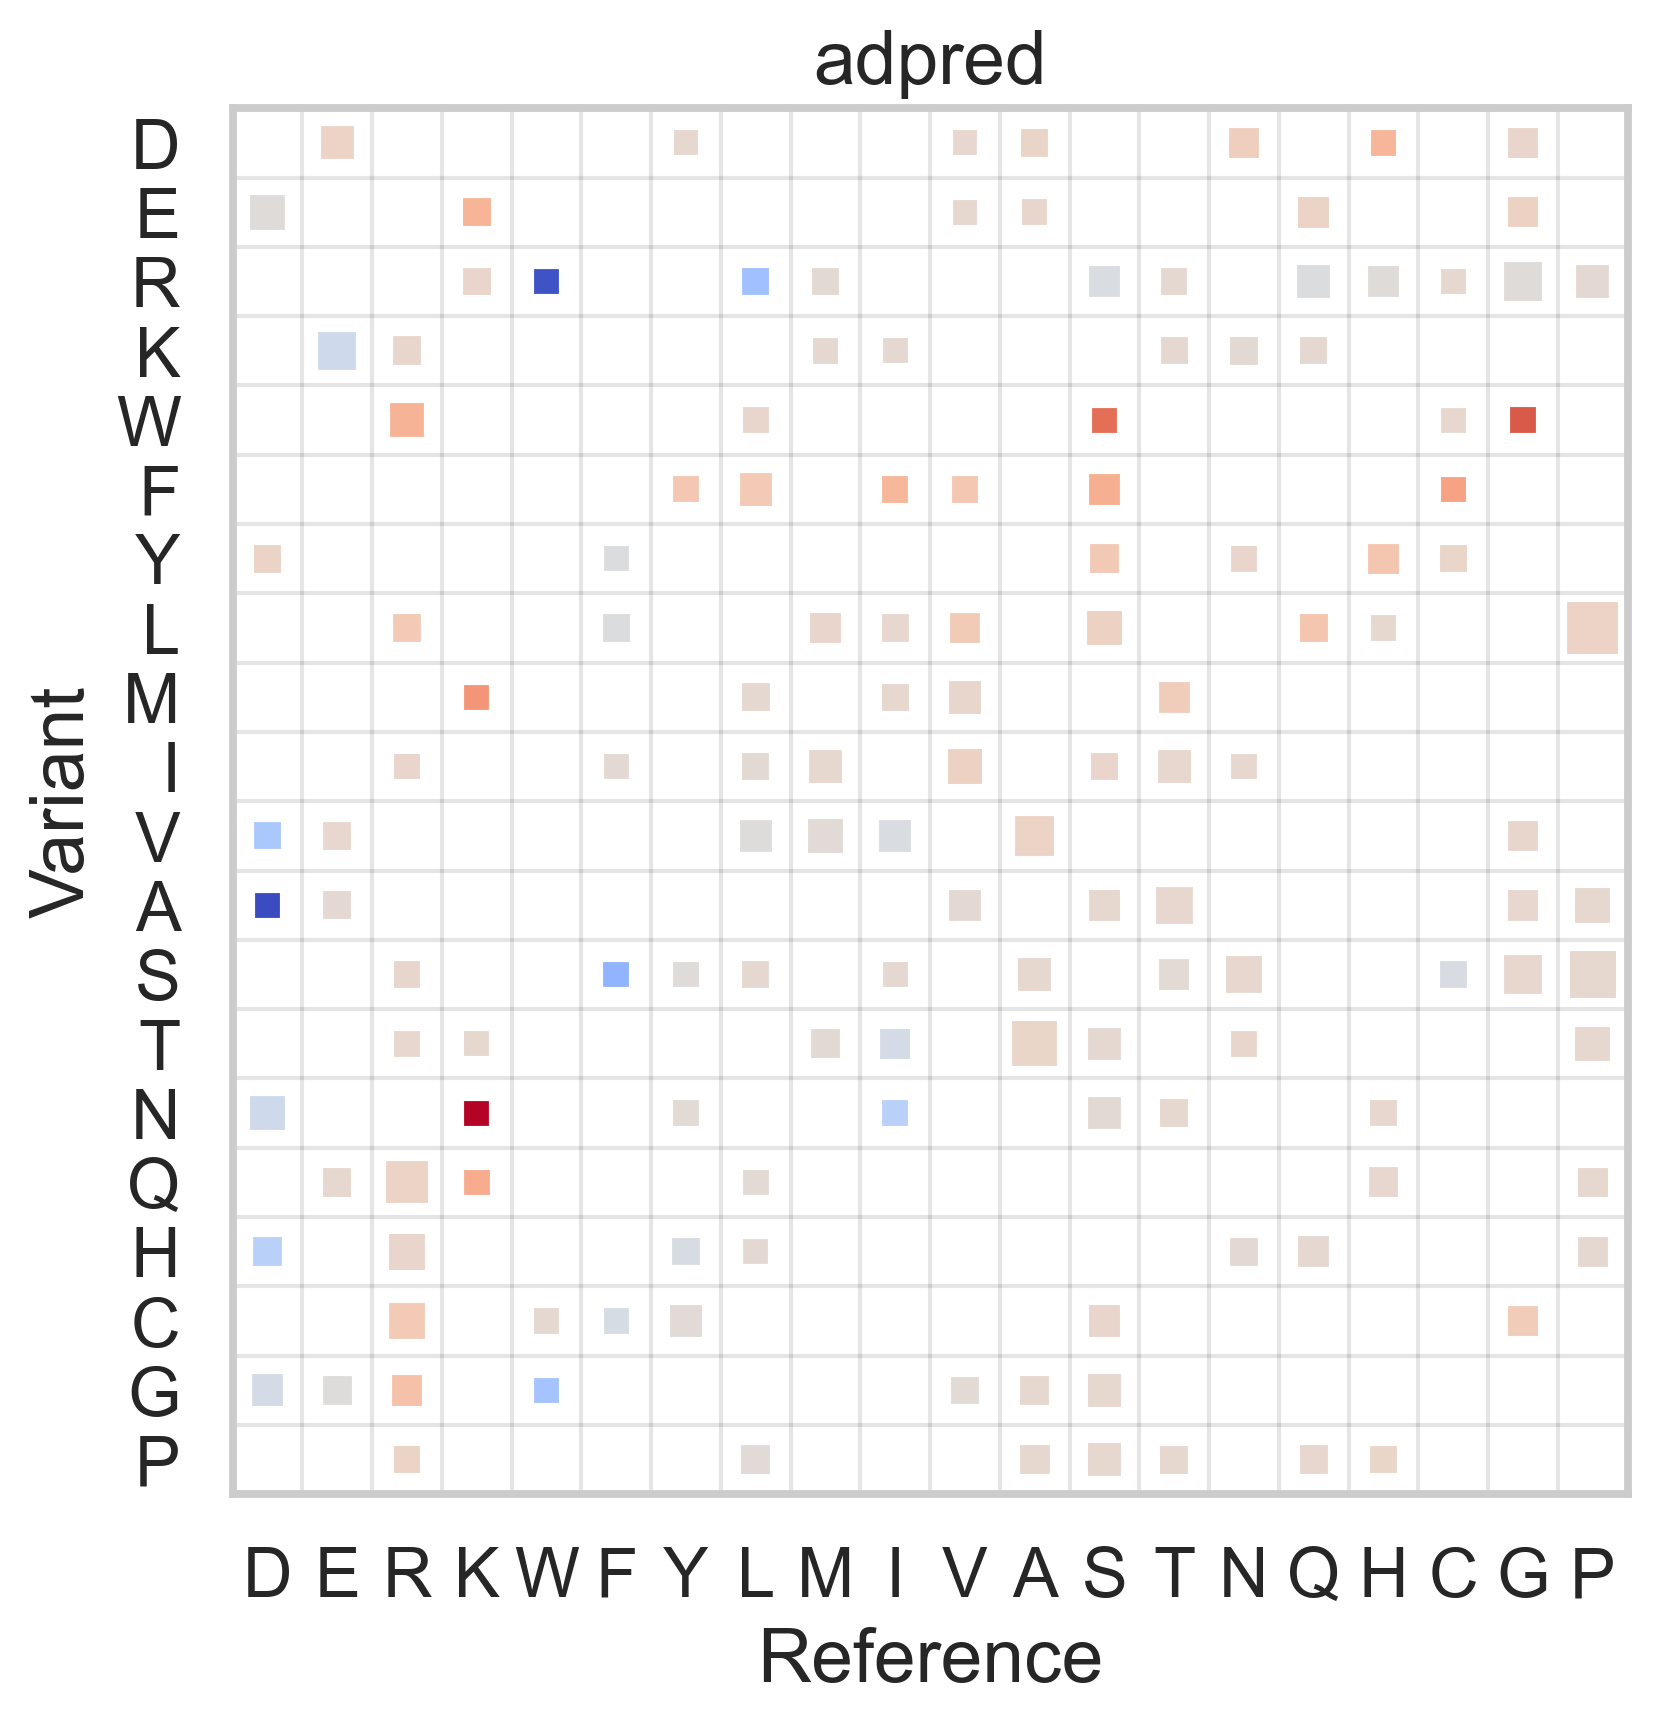

In [16]:
plot_2_heatmaps(summary, "adpred", "var_pos_adpred_activity", "ref_pos_adpred_activity")

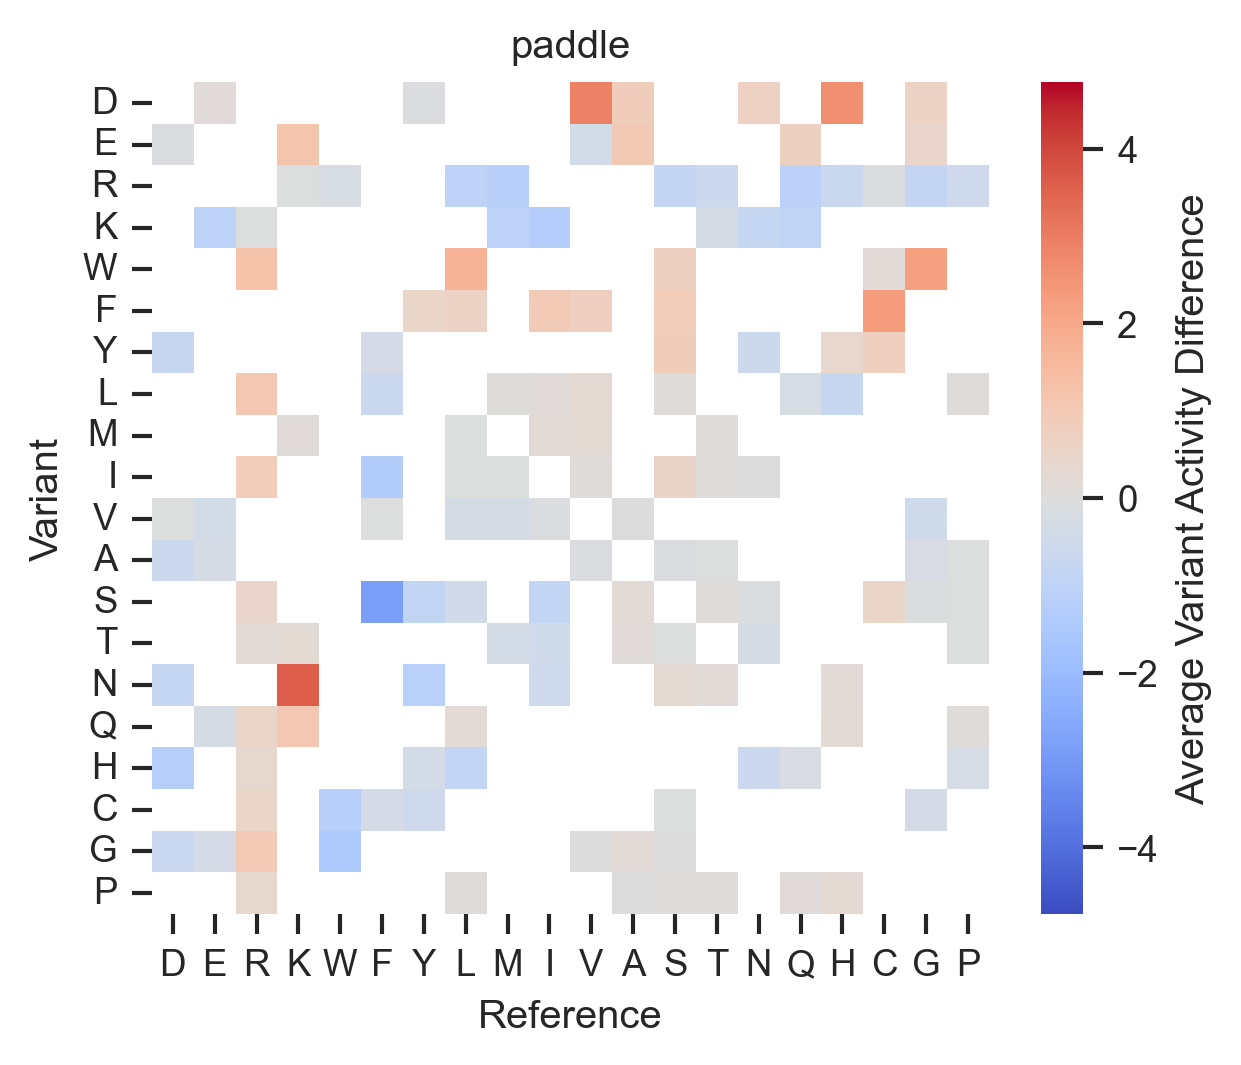

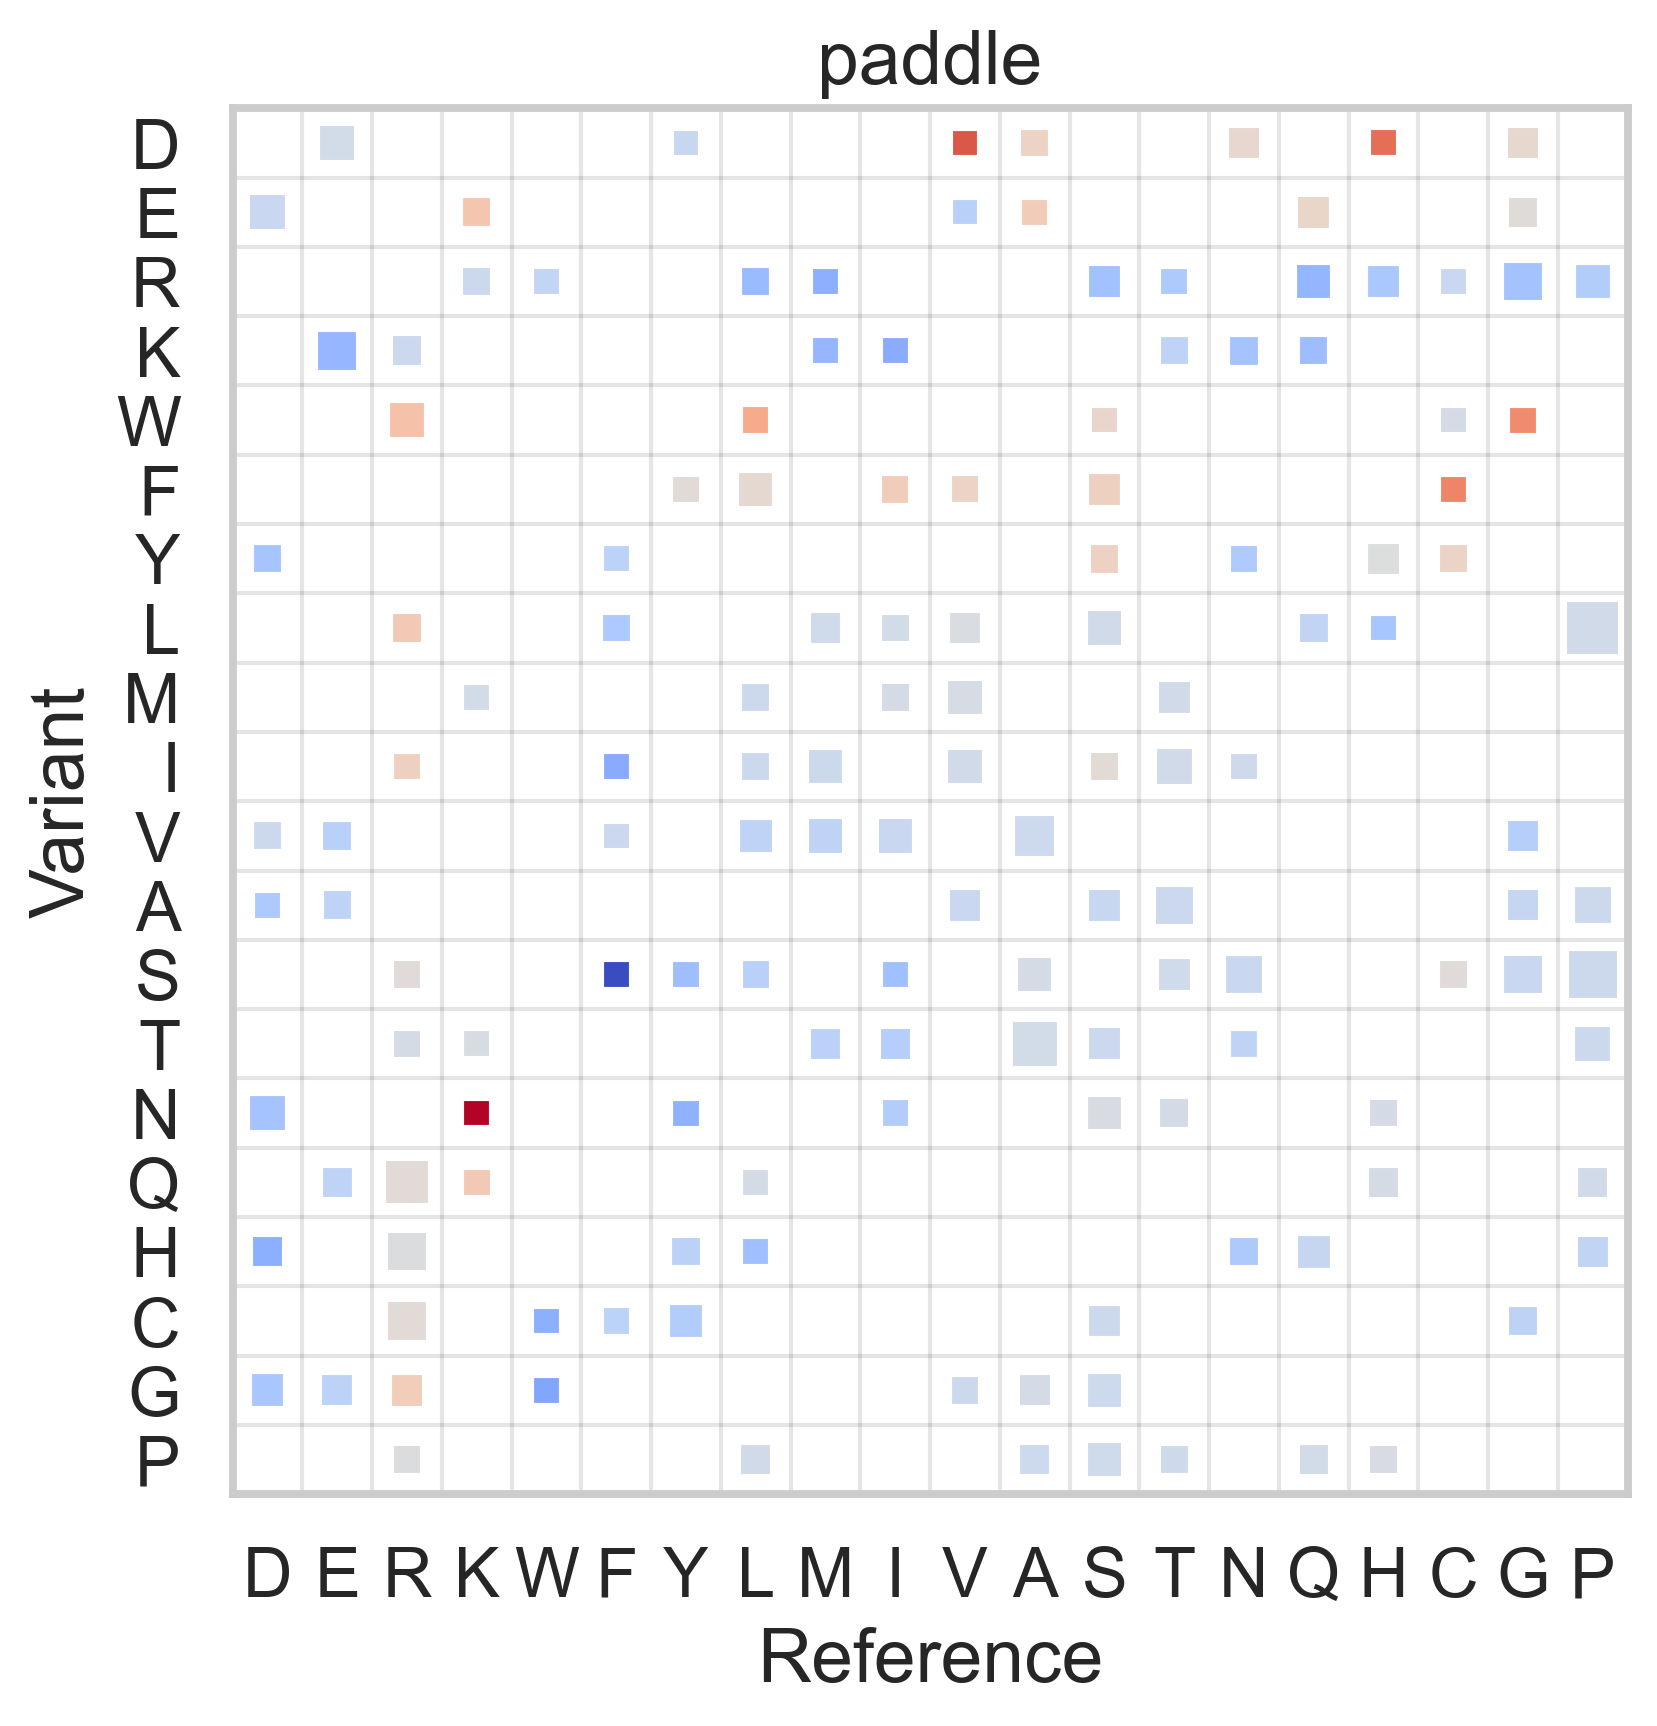

In [11]:
plot_2_heatmaps(summary, "paddle", "var_pred_paddle", "wt_pred_paddle")

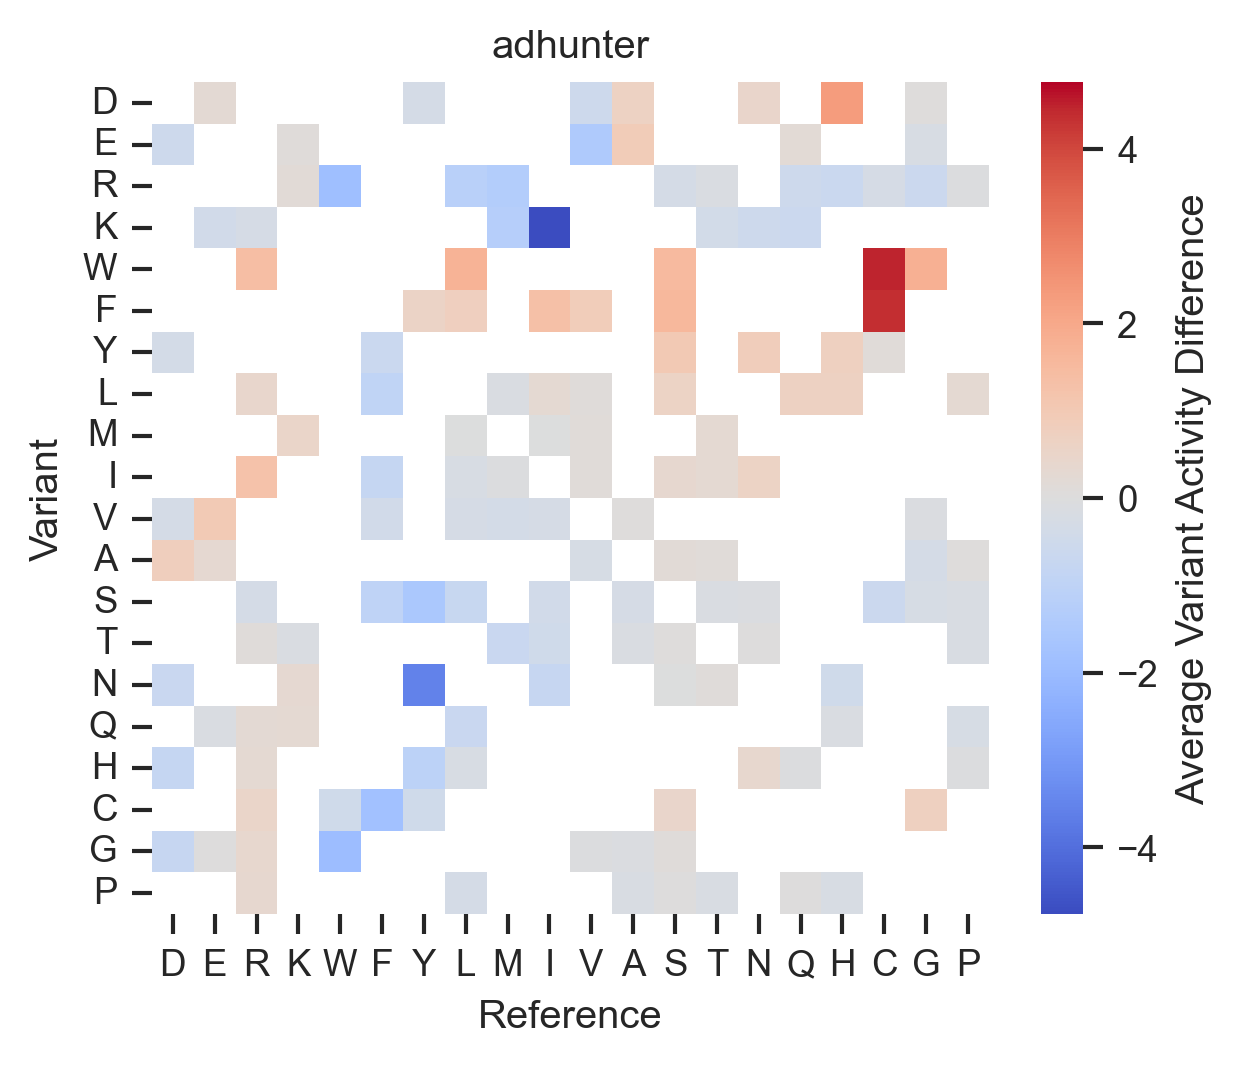

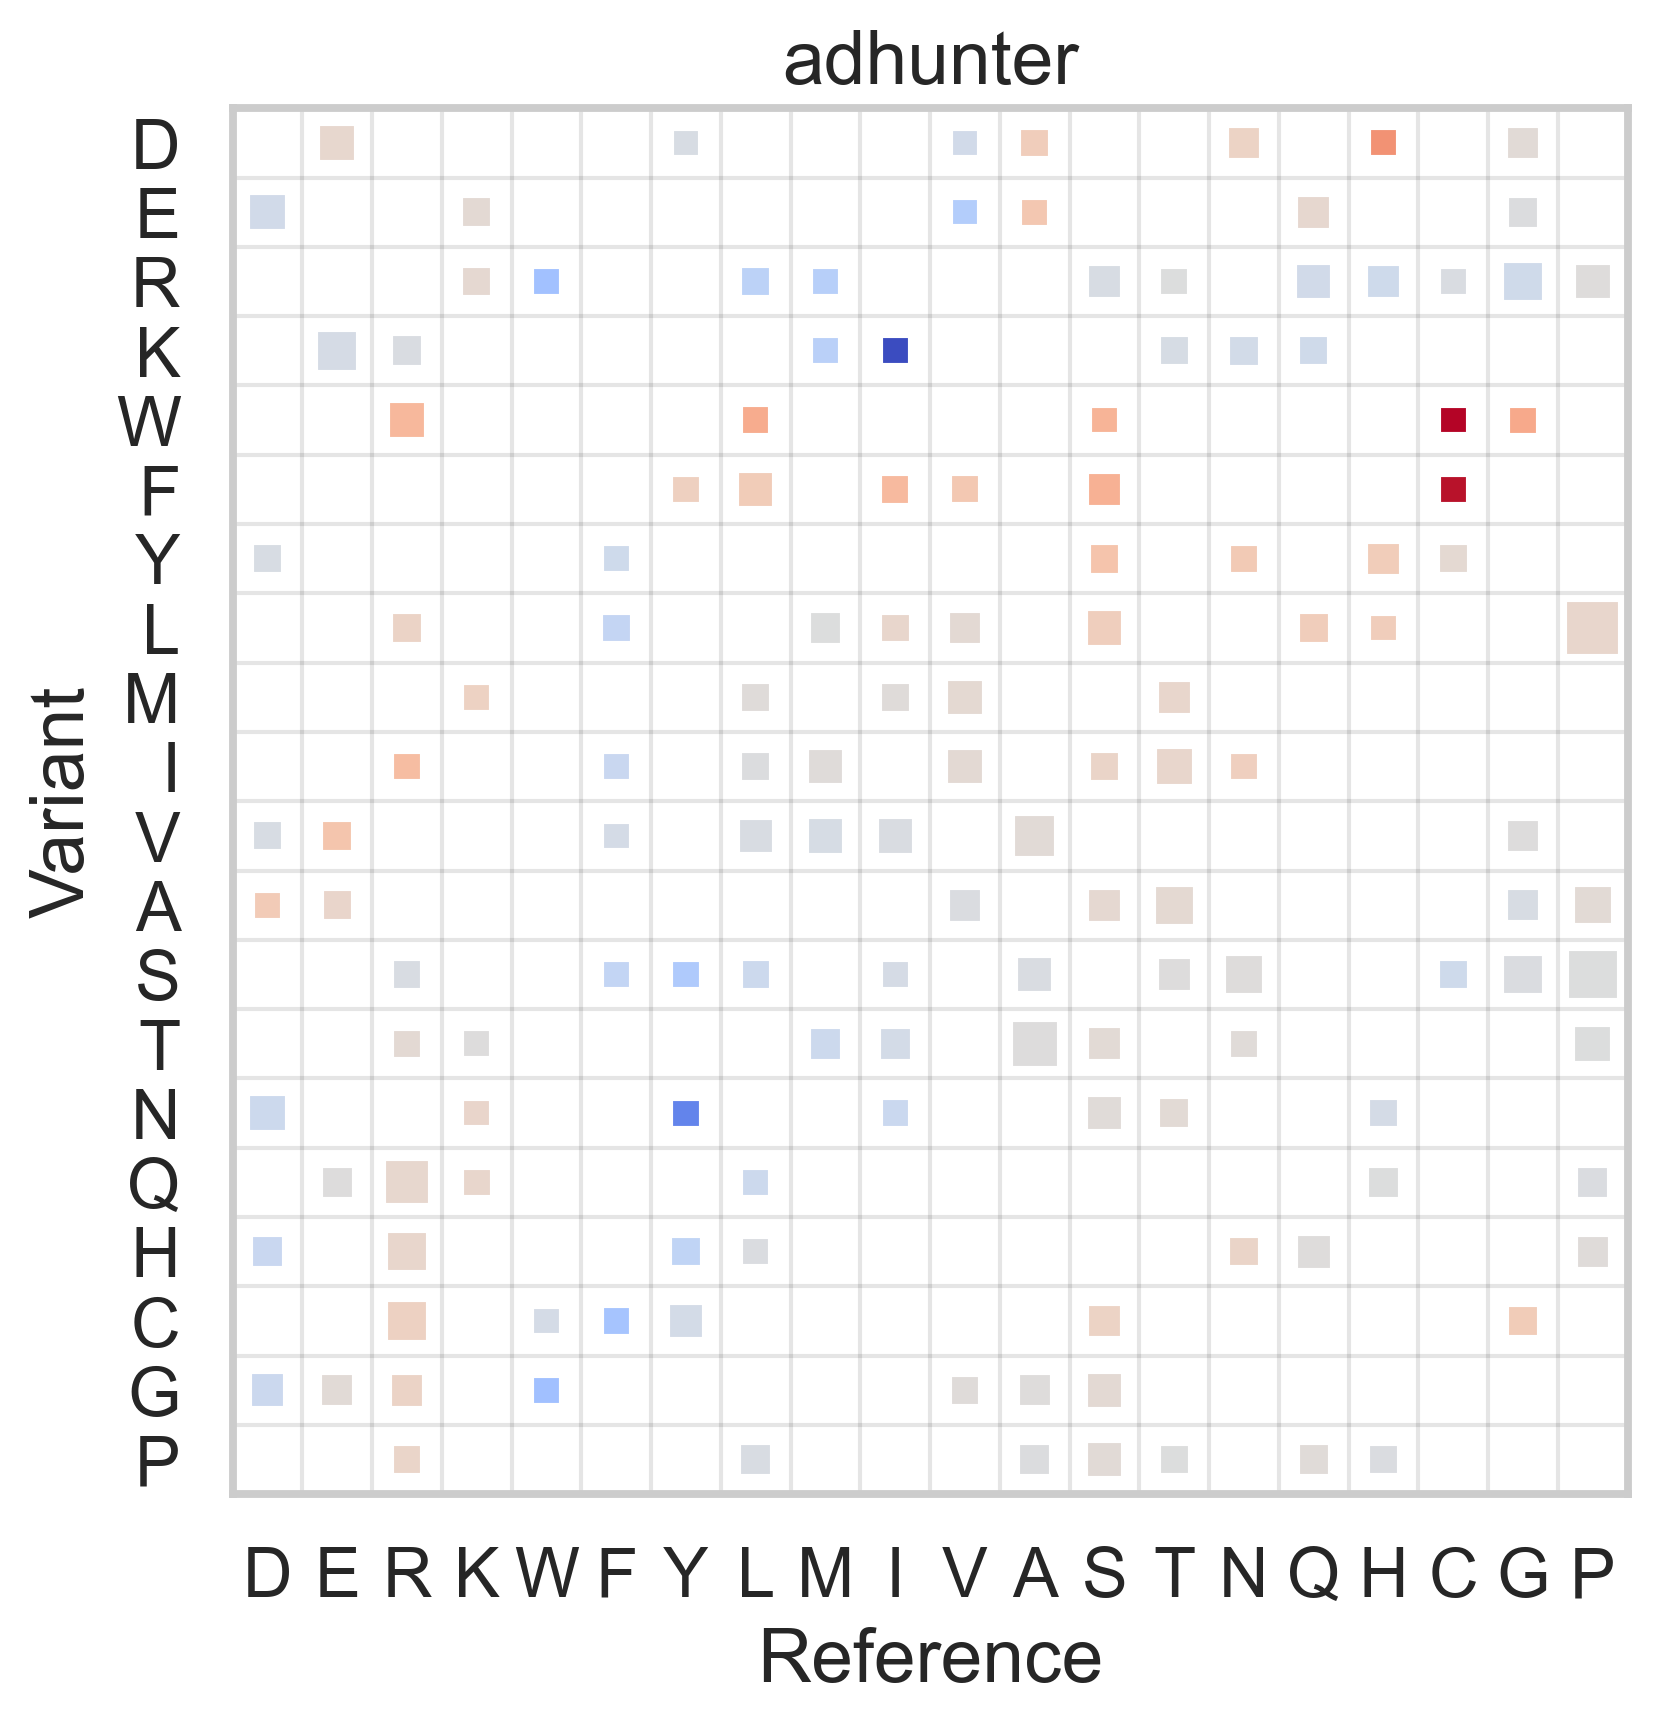

In [12]:
plot_2_heatmaps(summary, "adhunter", "var_pred_adhunter", "wt_pred_adhunter")